<a href="https://colab.research.google.com/github/yash25raj/ML/blob/main/Kinetex_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('diabetes2.csv')

# Display the first 5 rows
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

| Pregnancies   | Glucose   | BloodPressure   | SkinThickness   | Insulin   | BMI   | DiabetesPedigreeFunction   | Age   | Outcome   |
|:--------------|:----------|:----------------|:----------------|:----------|:------|:---------------------------|:------|:----------|
| 6             | 148       | 72              | 35              | 0         | 33.6  | 0.627                      | 50    | 1         |
| 1             | 85        | 66              | 29              | 0         | 26.6  | 0.351                      | 31    | 0         |
| 8             | 183       | 64              | 0               | 0         | 23.3  | 0.672                      | 32    | 1         |
| 1             | 89        | 66              | 23              | 94        | 28.1  | 0.167                      | 21    | 0         |
| 0             | 137       | 40              | 35              | 168       | 43.1  | 2.288                      | 33    | 1         |


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [4]:
print(df.describe().to_markdown(numalign="left", stralign="left"))

|       | Pregnancies   | Glucose   | BloodPressure   | SkinThickness   | Insulin   | BMI     | DiabetesPedigreeFunction   | Age     | Outcome   |
|:------|:--------------|:----------|:----------------|:----------------|:----------|:--------|:---------------------------|:--------|:----------|
| count | 768           | 768       | 768             | 768             | 768       | 768     | 768                        | 768     | 768       |
| mean  | 3.84505       | 120.895   | 69.1055         | 20.5365         | 79.7995   | 31.9926 | 0.471876                   | 33.2409 | 0.348958  |
| std   | 3.36958       | 31.9726   | 19.3558         | 15.9522         | 115.244   | 7.88416 | 0.331329                   | 11.7602 | 0.476951  |
| min   | 0             | 0         | 0               | 0               | 0         | 0       | 0.078                      | 21      | 0         |
| 25%   | 1             | 99        | 62              | 0               | 0         | 27.3    | 0.24375               

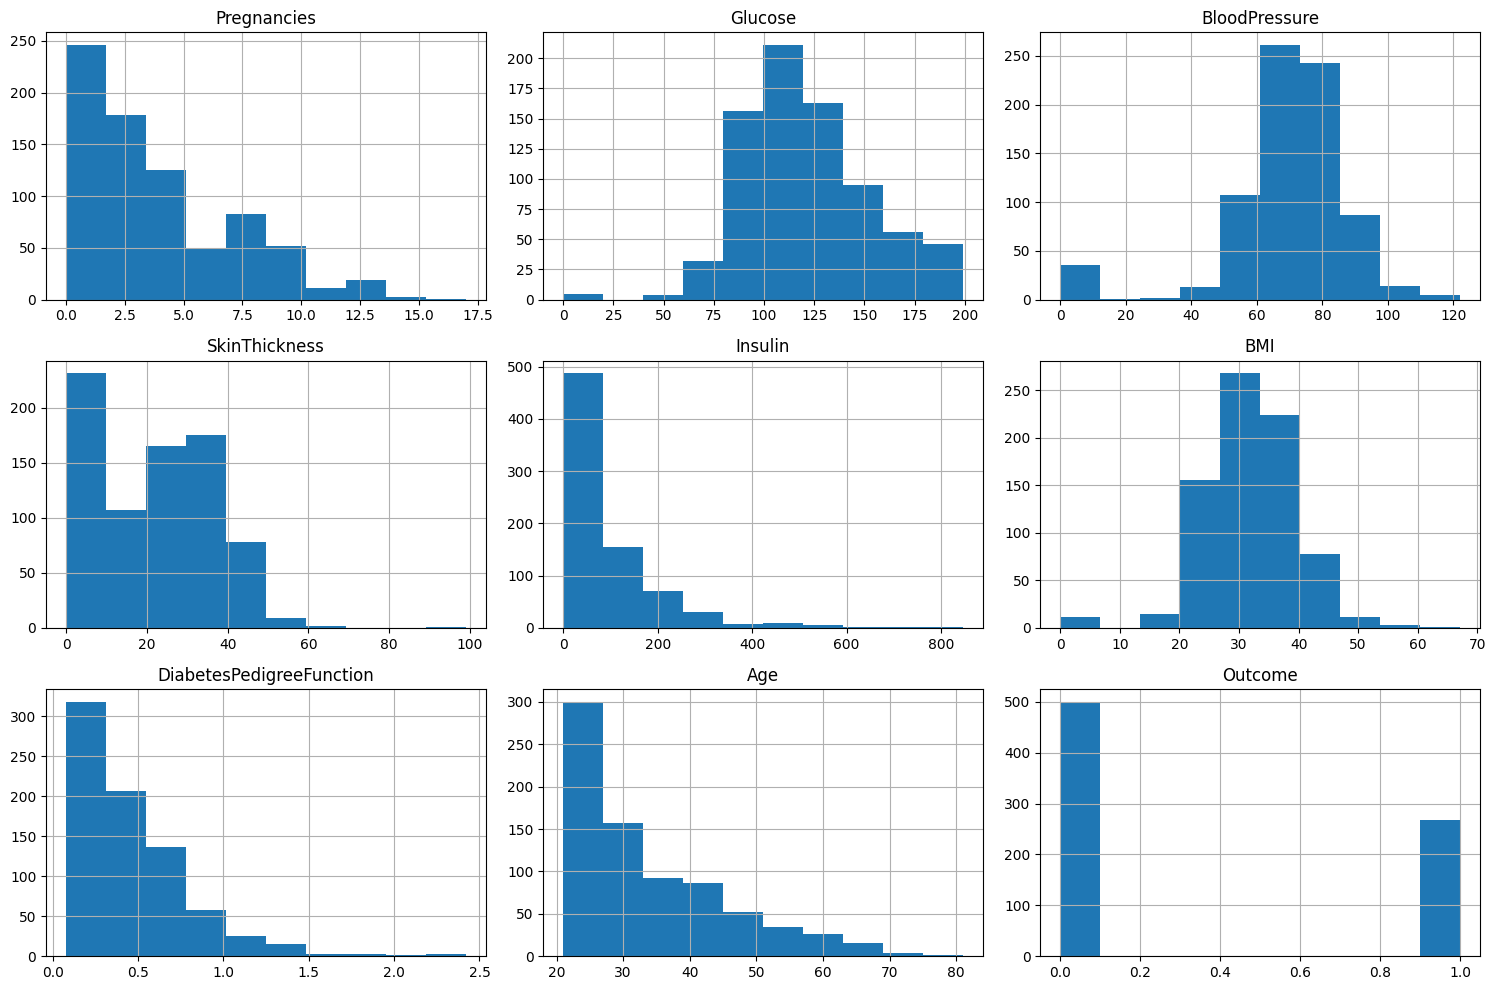

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(bins=10, figsize=(15, 10))
plt.tight_layout()
plt.show()

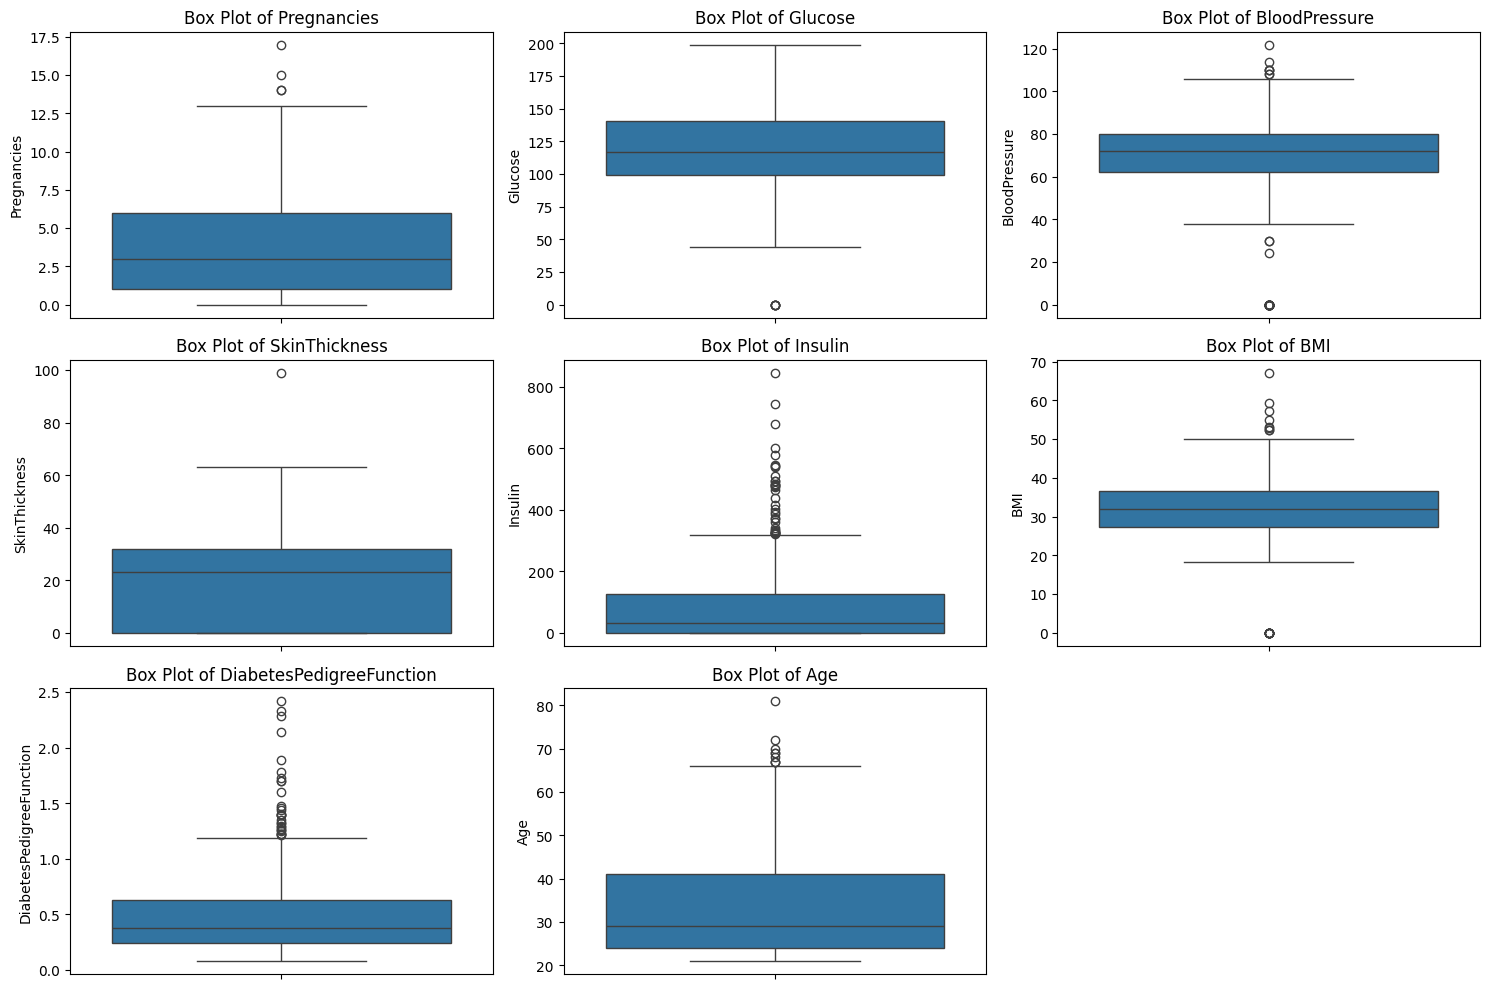

In [6]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns[:-1]): # Exclude 'Outcome'
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
plt.tight_layout()
plt.show()

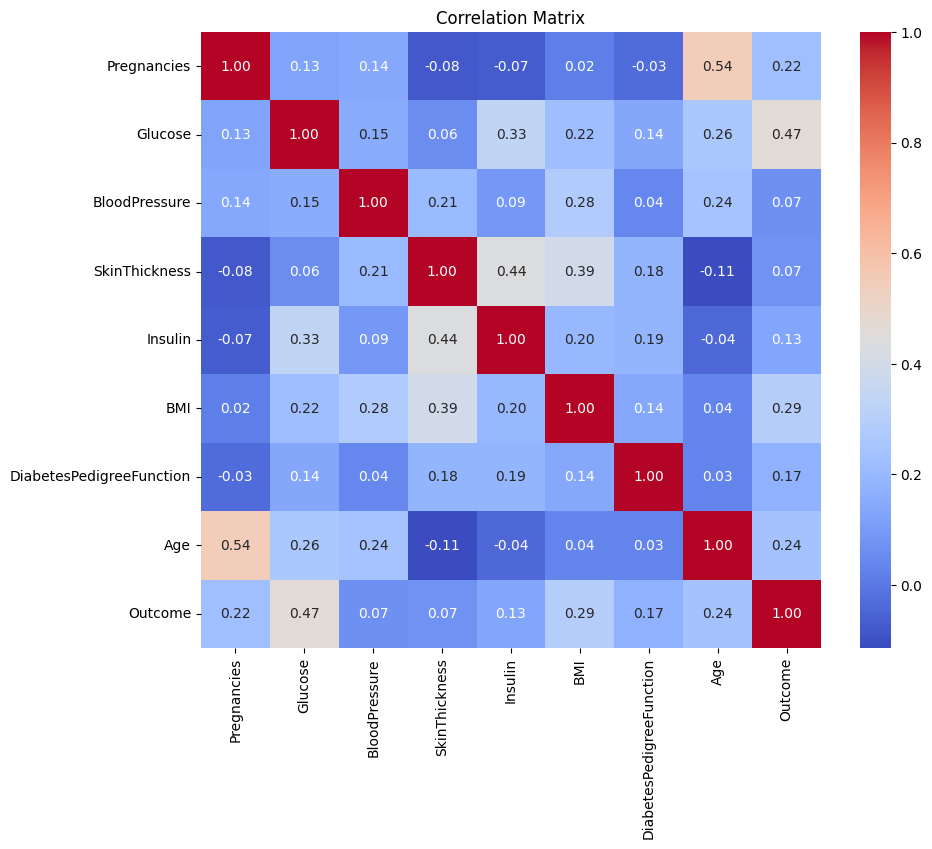

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [8]:
import numpy as np

# Columns with '0' values that represent missing data
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0s with NaN (use np.nan, not np.NaN)
df_processed = df.copy()
df_processed[columns_with_zeros] = df_processed[columns_with_zeros].replace(0, np.nan)

# Impute NaN values with the median for each outcome class
for col in columns_with_zeros:
    df_processed.loc[(df_processed['Outcome'] == 0) & (df_processed[col].isna()), col] = \
        df_processed[df_processed['Outcome'] == 0][col].median()
    df_processed.loc[(df_processed['Outcome'] == 1) & (df_processed[col].isna()), col] = \
        df_processed[df_processed['Outcome'] == 1][col].median()

# Verify that 0s are handled
print("Descriptive statistics after handling 0s:")
print(df_processed.describe().to_markdown(numalign="left", stralign="left"))


Descriptive statistics after handling 0s:
|       | Pregnancies   | Glucose   | BloodPressure   | SkinThickness   | Insulin   | BMI     | DiabetesPedigreeFunction   | Age     | Outcome   |
|:------|:--------------|:----------|:----------------|:----------------|:----------|:--------|:---------------------------|:--------|:----------|
| count | 768           | 768       | 768             | 768             | 768       | 768     | 768                        | 768     | 768       |
| mean  | 3.84505       | 121.677   | 72.3893         | 29.0898         | 141.754   | 32.4346 | 0.471876                   | 33.2409 | 0.348958  |
| std   | 3.36958       | 30.4642   | 12.106          | 8.89082         | 89.1008   | 6.8805  | 0.331329                   | 11.7602 | 0.476951  |
| min   | 0             | 44        | 24              | 7               | 14        | 18.2    | 0.078                      | 21      | 0         |
| 25%   | 1             | 99.75     | 64              | 25              | 10

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_processed.drop('Outcome', axis=1)
y = df_processed['Outcome']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale the test data using the same scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for better readability (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\nFirst 5 rows of scaled training data:")
print(X_train_scaled_df.head().to_markdown(numalign="left", stralign="left"))


First 5 rows of scaled training data:
|     | Pregnancies   | Glucose   | BloodPressure   | SkinThickness   | Insulin   | BMI       | DiabetesPedigreeFunction   | Age       |
|:----|:--------------|:----------|:----------------|:----------------|:----------|:----------|:---------------------------|:----------|
| 353 | -0.851355     | -1.05687  | -0.826687       | -1.89529        | -1.17038  | -0.76615  | 0.310794                   | -0.792169 |
| 711 | 0.356576      | 0.142855  | 0.477009        | -0.224736       | -1.42764  | -0.414448 | -0.116439                  | 0.561034  |
| 373 | -0.549372     | -0.556984 | -1.15261        | 1.22308         | -0.545594 | 0.362227  | -0.764862                  | -0.707594 |
| 46  | -0.851355     | 0.809369  | -1.31557        | -0.224736       | -0.441463 | -0.399794 | 0.262314                   | -0.369293 |
| 682 | -1.15334      | -0.890241 | -0.663725       | 1.11171         | -0.410836 | 1.78369   | -0.33763                   | -0.96132  |


In [10]:
# Re-load the original data to apply feature engineering before splitting and scaling again
df_fe = df.copy()

# Replace 0s with NaN for imputation
df_fe[columns_with_zeros] = df_fe[columns_with_zeros].replace(0, np.nan)

# Impute NaN values with the median for each outcome class
for col in columns_with_zeros:
    df_fe.loc[(df_fe['Outcome'] == 0) & (df_fe[col].isna()), col] = \
        df_fe[df_fe['Outcome'] == 0][col].median()
    df_fe.loc[(df_fe['Outcome'] == 1) & (df_fe[col].isna()), col] = \
        df_fe[df_fe['Outcome'] == 1][col].median()

# Feature Engineering
# 1. BMI Category
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 24.9:
        return 'Normal'
    elif 24.9 <= bmi < 29.9:
        return 'Overweight'
    else:
        return 'Obese'

df_fe['BMI_Category'] = df_fe['BMI'].apply(bmi_category)

# Convert BMI_Category to numerical using one-hot encoding or ordinal encoding
# For simplicity, we'll use one-hot encoding here, which will be handled by our scaler later
df_fe = pd.get_dummies(df_fe, columns=['BMI_Category'], drop_first=True) # drop_first to avoid multicollinearity

# 2. Glucose-Insulin Ratio (handle division by zero if Insulin could be 0, though we imputed it)
df_fe['Glucose_Insulin_Ratio'] = df_fe['Glucose'] / (df_fe['Insulin'] + 1e-6) # Add small epsilon to avoid div by zero

# 3. BP_BMI_Interaction
df_fe['BP_BMI_Interaction'] = df_fe['BloodPressure'] * df_fe['BMI']

print("\nFirst 5 rows of data with new engineered features:")
print(df_fe.head().to_markdown(numalign="left", stralign="left"))


First 5 rows of data with new engineered features:
|    | Pregnancies   | Glucose   | BloodPressure   | SkinThickness   | Insulin   | BMI   | DiabetesPedigreeFunction   | Age   | Outcome   | BMI_Category_Obese   | BMI_Category_Overweight   | BMI_Category_Underweight   | Glucose_Insulin_Ratio   | BP_BMI_Interaction   |
|:---|:--------------|:----------|:----------------|:----------------|:----------|:------|:---------------------------|:------|:----------|:---------------------|:--------------------------|:---------------------------|:------------------------|:---------------------|
| 0  | 6             | 148       | 72              | 35              | 169.5     | 33.6  | 0.627                      | 50    | 1         | True                 | False                     | False                      | 0.873156                | 2419.2               |
| 1  | 1             | 85        | 66              | 29              | 102.5     | 26.6  | 0.351                      | 31    | 0         | F

In [11]:
# Separate features (X_fe) and target (y_fe)
X_fe = df_fe.drop('Outcome', axis=1)
y_fe = df_fe['Outcome']

# Split the data into training and testing sets with new features
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe)

# Initialize StandardScaler
scaler_fe = StandardScaler()

# Scale the training data with new features
X_train_scaled_fe = scaler_fe.fit_transform(X_train_fe)

# Scale the test data using the same scaler fitted on the training data
X_test_scaled_fe = scaler_fe.transform(X_test_fe)

# Convert scaled arrays back to DataFrames for better readability (optional)
X_train_scaled_fe_df = pd.DataFrame(X_train_scaled_fe, columns=X_fe.columns, index=X_train_fe.index)
X_test_scaled_fe_df = pd.DataFrame(X_test_scaled_fe, columns=X_fe.columns, index=X_test_fe.index)

print("\nFirst 5 rows of scaled training data with engineered features:")
print(X_train_scaled_fe_df.head().to_markdown(numalign="left", stralign="left"))


First 5 rows of scaled training data with engineered features:
|     | Pregnancies   | Glucose   | BloodPressure   | SkinThickness   | Insulin   | BMI       | DiabetesPedigreeFunction   | Age       | BMI_Category_Obese   | BMI_Category_Overweight   | BMI_Category_Underweight   | Glucose_Insulin_Ratio   | BP_BMI_Interaction   |
|:----|:--------------|:----------|:----------------|:----------------|:----------|:----------|:---------------------------|:----------|:---------------------|:--------------------------|:---------------------------|:------------------------|:---------------------|
| 353 | -0.851355     | -1.05687  | -0.826687       | -1.89529        | -1.17038  | -0.76615  | 0.310794                   | -0.792169 | -1.32882             | 1.85722                   | -0.0700713                 | 1.64332                 | -0.90476             |
| 711 | 0.356576      | 0.142855  | 0.477009        | -0.224736       | -1.42764  | -0.414448 | -0.116439                  | 0.561034  | -

--- Logistic Regression (Original Features) ---
Accuracy: 0.7078
Precision: 0.5882
Recall: 0.5556
F1-Score: 0.5714
ROC AUC Score: 0.8263


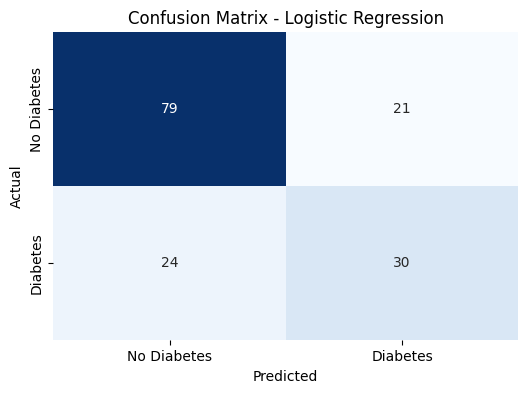

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the model
lr_model = LogisticRegression(random_state=42, solver='liblinear')

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("--- Logistic Regression (Original Features) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

DataFrame with New Features (first 5 rows):
| Pregnancies   | Glucose   | BloodPressure   | SkinThickness   | Insulin   | BMI   | DiabetesPedigreeFunction   | Age   | Outcome   | BMI_Category   | Glucose_Insulin_Ratio   | BP_BMI_Interaction   | Age_Group   |
|:--------------|:----------|:----------------|:----------------|:----------|:------|:---------------------------|:------|:----------|:---------------|:------------------------|:---------------------|:------------|
| 6             | 148       | 72              | 35              | 169.5     | 33.6  | 0.627                      | 50    | 1         | 3              | 0.873156                | 2419.2               | 2           |
| 1             | 85        | 66              | 29              | 102.5     | 26.6  | 0.351                      | 31    | 0         | 2              | 0.829268                | 1755.6               | 1           |
| 8             | 183       | 64              | 32              | 169.5     | 23.3  | 0.672     

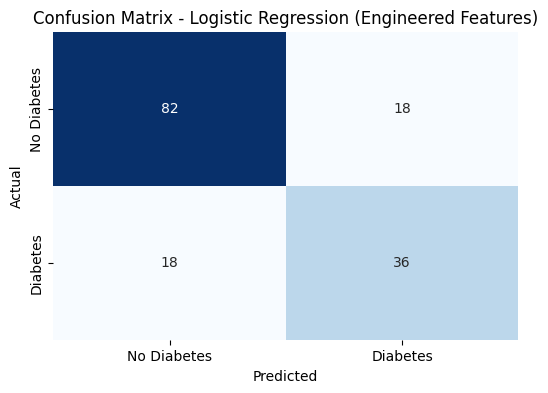

In [13]:
import numpy as np

# Create new features
df_fe = df_processed.copy() # Assuming df_imputed is your DataFrame after handling zeros/imputation

# 1. BMI Category
def bmi_category(bmi):
    if bmi < 18.5:
        return 0 # Underweight
    elif 18.5 <= bmi < 25:
        return 1 # Normal weight
    elif 25 <= bmi < 30:
        return 2 # Overweight
    else:
        return 3 # Obese

df_fe['BMI_Category'] = df_fe['BMI'].apply(bmi_category)

# 2. Glucose-Insulin Ratio (handle division by zero for Insulin if 0s are still present)
# Assuming 0s in Insulin have been imputed. If not, consider adding a small epsilon or handling.
# For simplicity, we'll assume imputed values are non-zero where appropriate.
# If there are still 0s in Insulin after imputation, they should ideally be handled before this step.
# For now, let's proceed assuming Insulin is properly handled.
df_fe['Glucose_Insulin_Ratio'] = df_fe['Glucose'] / (df_fe['Insulin'] + 1e-6) # Add epsilon to avoid division by zero

# 3. BloodPressure-BMI Interaction
df_fe['BP_BMI_Interaction'] = df_fe['BloodPressure'] * df_fe['BMI']

# 4. Age Group
def age_group(age):
    if age < 30:
        return 0 # Young Adult
    elif 30 <= age < 50:
        return 1 # Middle-aged Adult
    else:
        return 2 # Senior

df_fe['Age_Group'] = df_fe['Age'].apply(age_group)

print("DataFrame with New Features (first 5 rows):")
print(df_fe.head().to_markdown(index=False, numalign="left", stralign="left"))

# Prepare data for model training with new features
X_fe = df_fe.drop('Outcome', axis=1)
y_fe = df_fe['Outcome']

# Split data
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe)

# Scale new features
scaler_fe = StandardScaler()
X_train_scaled_fe = scaler_fe.fit_transform(X_train_fe)
X_test_scaled_fe = scaler_fe.transform(X_test_fe)

# Train Logistic Regression model with new features
lr_model_fe = LogisticRegression(random_state=42, solver='liblinear')
lr_model_fe.fit(X_train_scaled_fe, y_train_fe)

# Make predictions
y_pred_lr_fe = lr_model_fe.predict(X_test_scaled_fe)
y_prob_lr_fe = lr_model_fe.predict_proba(X_test_scaled_fe)[:, 1]

# Evaluate the model with new features
print("\n--- Logistic Regression (with Engineered Features) ---")
print(f"Accuracy: {accuracy_score(y_test_fe, y_pred_lr_fe):.4f}")
print(f"Precision: {precision_score(y_test_fe, y_pred_lr_fe):.4f}")
print(f"Recall: {recall_score(y_test_fe, y_pred_lr_fe):.4f}")
print(f"F1-Score: {f1_score(y_test_fe, y_pred_lr_fe):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_fe, y_prob_lr_fe):.4f}")

# Confusion Matrix for engineered features
cm_lr_fe = confusion_matrix(y_test_fe, y_pred_lr_fe)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr_fe, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Logistic Regression (Engineered Features)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


--- Random Forest Classifier (with Engineered Features) ---
Accuracy: 0.8636
Precision: 0.8235
Recall: 0.7778
F1-Score: 0.8000
ROC AUC Score: 0.9447


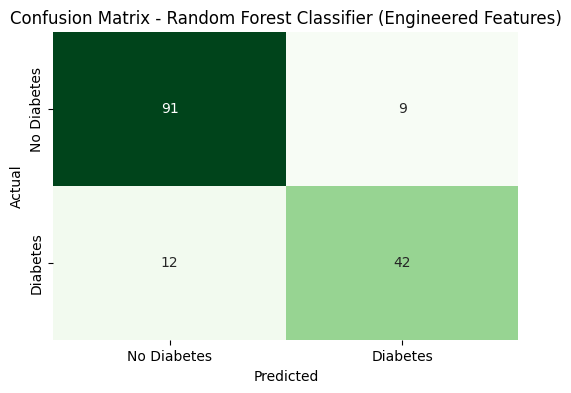

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
# We'll start with default parameters, then tune if it performs well
rf_model = RandomForestClassifier(random_state=42)

# Train the model using the scaled engineered features
# X_train_scaled_fe, y_train_fe were prepared earlier after feature engineering
rf_model.fit(X_train_scaled_fe, y_train_fe)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled_fe)
y_prob_rf = rf_model.predict_proba(X_test_scaled_fe)[:, 1]

# Evaluate the Random Forest model
print("\n--- Random Forest Classifier (with Engineered Features) ---")
print(f"Accuracy: {accuracy_score(y_test_fe, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test_fe, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test_fe, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test_fe, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_fe, y_prob_rf):.4f}")

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test_fe, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Random Forest Classifier (Engineered Features)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
540 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/uti


GridSearchCV completed!
Best parameters found: {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best cross-validation ROC AUC score: 0.9408

--- Tuned Random Forest Classifier (with Engineered Features) ---
Accuracy: 0.8896
Precision: 0.8491
Recall: 0.8333
F1-Score: 0.8411
ROC AUC Score: 0.9533


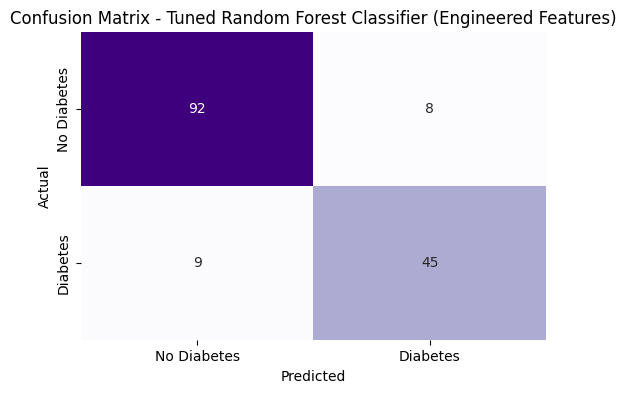

In [15]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],   # Minimum samples required at a leaf node
    'max_features': ['auto', 'sqrt', 0.8] # Number of features to consider for best split
}

# Initialize GridSearchCV
# We'll use the 'roc_auc' scoring as it's often a good choice for imbalanced classification
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5, # 5-fold cross-validation
                           n_jobs=-1, # Use all available cores
                           verbose=2, # Display progress
                           scoring='roc_auc')

# Fit GridSearchCV to the training data (using engineered features)
print("\nStarting GridSearchCV for Random Forest...")
grid_search.fit(X_train_scaled_fe, y_train_fe)

print("\nGridSearchCV completed!")

# Get the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation ROC AUC score: {grid_search.best_score_:.4f}")

# Get the best estimator (the trained model with the best parameters)
best_rf_model = grid_search.best_estimator_

# Make predictions with the best model on the test set
y_pred_best_rf = best_rf_model.predict(X_test_scaled_fe)
y_prob_best_rf = best_rf_model.predict_proba(X_test_scaled_fe)[:, 1]

# Evaluate the best Random Forest model
print("\n--- Tuned Random Forest Classifier (with Engineered Features) ---")
print(f"Accuracy: {accuracy_score(y_test_fe, y_pred_best_rf):.4f}")
print(f"Precision: {precision_score(y_test_fe, y_pred_best_rf):.4f}")
print(f"Recall: {recall_score(y_test_fe, y_pred_best_rf):.4f}")
print(f"F1-Score: {f1_score(y_test_fe, y_pred_best_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_fe, y_prob_best_rf):.4f}")

# Confusion Matrix for Tuned Random Forest
cm_best_rf = confusion_matrix(y_test_fe, y_pred_best_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best_rf, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Tuned Random Forest Classifier (Engineered Features)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


--- Feature Importances from Tuned Random Forest ---
| feature                  | importance   |
|:-------------------------|:-------------|
| Insulin                  | 0.586851     |
| Glucose                  | 0.109012     |
| SkinThickness            | 0.0803618    |
| Age                      | 0.061173     |
| Glucose_Insulin_Ratio    | 0.0494995    |
| BP_BMI_Interaction       | 0.0306899    |
| DiabetesPedigreeFunction | 0.0269622    |
| BMI                      | 0.0247074    |
| BloodPressure            | 0.0125605    |
| Pregnancies              | 0.0117356    |
| Age_Group                | 0.00567272   |
| BMI_Category             | 0.000774668  |


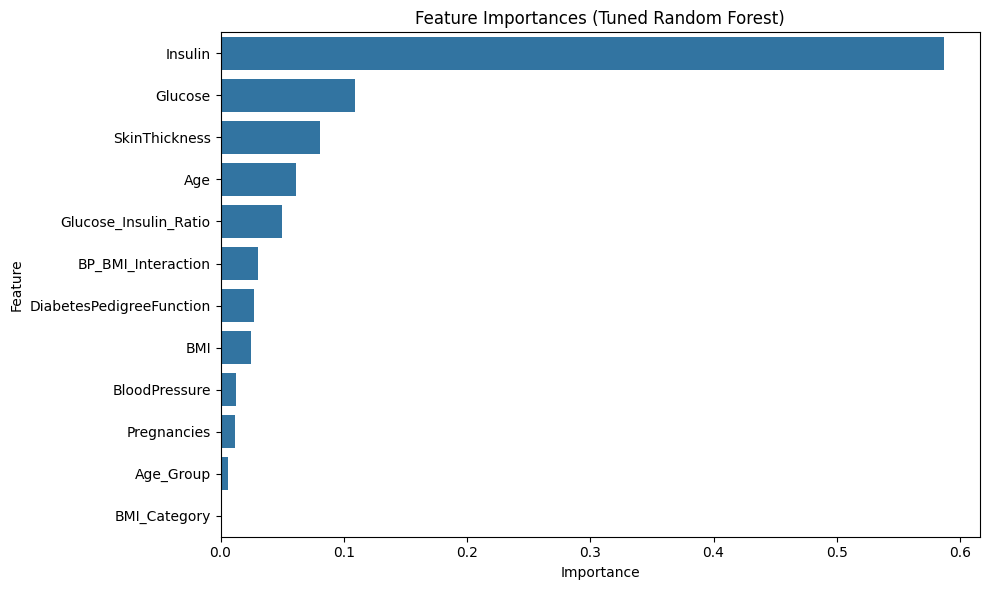

In [16]:
# Get feature importances from the best Random Forest model
importances = best_rf_model.feature_importances_

# Get feature names (assuming X_fe was used for training)
feature_names = X_fe.columns

# Create a DataFrame for better visualization
feature_importances_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# Sort features by importance
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

print("\n--- Feature Importances from Tuned Random Forest ---")
print(feature_importances_df.to_markdown(index=False, numalign="left", stralign="left"))

# Plotting feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances_df)
plt.title('Feature Importances (Tuned Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


Training XGBoost Classifier...
XGBoost Training completed!

--- XGBoost Classifier (with Engineered Features) ---
Accuracy: 0.8831
Precision: 0.8333
Recall: 0.8333
F1-Score: 0.8333
ROC AUC Score: 0.9450


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:49:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


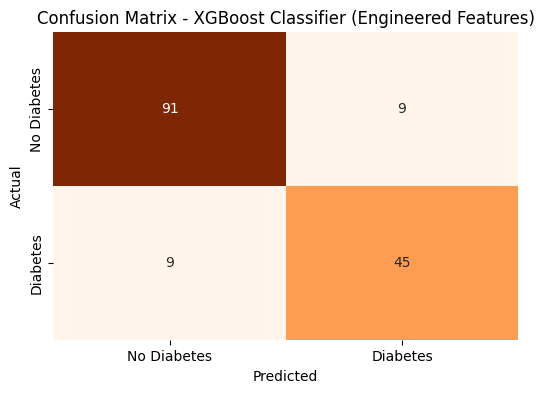

In [17]:
from xgboost import XGBClassifier

# Initialize the XGBoost model
# We'll use a few common parameters that often work well,
# but note that extensive tuning could further improve it.
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                          use_label_encoder=False, random_state=42)

# Train the model using the scaled engineered features
# X_train_scaled_fe, y_train_fe were prepared earlier after feature engineering
print("\nTraining XGBoost Classifier...")
xgb_model.fit(X_train_scaled_fe, y_train_fe)
print("XGBoost Training completed!")

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_scaled_fe)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled_fe)[:, 1]

# Evaluate the XGBoost model
print("\n--- XGBoost Classifier (with Engineered Features) ---")
print(f"Accuracy: {accuracy_score(y_test_fe, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test_fe, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test_fe, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test_fe, y_pred_xgb):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_fe, y_prob_xgb):.4f}")

# Confusion Matrix for XGBoost
cm_xgb = confusion_matrix(y_test_fe, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - XGBoost Classifier (Engineered Features)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [18]:
import joblib

# Save the best model (XGBoost in this case)
model_filename = 'best_diabetes_prediction_model.joblib'
joblib.dump(xgb_model, model_filename) # Using xgb_model as it was the best

print(f"\nBest model (XGBoost Classifier) saved as '{model_filename}'")

# Example of how to load the model later:
# loaded_model = joblib.load(model_filename)
# new_predictions = loaded_model.predict(new_data_scaled)


Best model (XGBoost Classifier) saved as 'best_diabetes_prediction_model.joblib'
